<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/lecture_notes/notebooks/10_Cointegration_and_VECM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 실습: 공적분과 장기균형 관계
**Notebook:** `10_Cointegration_and_VECM.ipynb`

## 실습 목표 (Learning Objectives)
이 실습에서는 다음을 수행합니다.

1. 비정상 시계열을 그대로 회귀하면 왜 가짜 회귀(Spurious Regression)가 발생할 수 있는지 확인합니다.
2. 단위근을 가진 두 시계열이 장기적으로 함께 움직이는 공적분(Cointegration) 관계를 직관적으로 이해합니다.
3. Engle–Granger 2단계 검정을 이용해 공적분 여부를 확인합니다.
4. Johansen 공적분 rank 선택 절차를 통해 다변량 공적분 관점을 확인합니다.
5. VECM(Vector Error Correction Model)을 적합하여 단기 변동과 장기 균형 복귀를 동시에 모델링합니다.
6. 오차수정항(Error Correction Term)과 조정속도(Adjustment Speed)를 해석합니다.
7. 테스트 구간 예측을 통해 VECM의 활용 방식을 확인합니다.

---

## 왜 이 실습이 중요한가?
경제와 경영의 많은 시계열은 수준(level)에서는 비정상적입니다.  
예를 들어 소득, 소비, 가격, 환율, 자산가격은 시간이 지남에 따라 장기 추세를 보일 수 있습니다.

이때 모든 변수를 단순 차분해 버리면 단기 변화는 잘 보이지만,  
원래 변수들 사이에 존재하던 **장기 수준 관계(long-run equilibrium relationship)** 를 잃어버릴 수 있습니다.

이번 실습의 핵심은 다음 질문에 답하는 것입니다.

- 두 비정상 시계열이 정말 함께 움직이는가?
- 그 관계가 단순 상관이 아니라 장기 균형인가?
- 균형에서 벗어났을 때 어느 변수가 얼마나 빠르게 복귀하는가?

이 질문에 답하는 도구가 바로 공적분과 VECM입니다.


In [1]:
# ============================================
# 1. 필수 라이브러리 불러오기
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from IPython.display import display


## 1. 시각화 기본 설정
이번 버전도 Colab 호환성을 위해 **그래프 텍스트는 영어**로 출력합니다.  
마크다운 셀과 코드 주석은 한글로 유지합니다.


In [2]:
# ============================================
# 2. 시각화 기본 설정
# ============================================

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.unicode_minus"] = False


## 2. 실습용 거시경제 데이터 불러오기
이번 실습에서는 `statsmodels`의 **macrodata**를 사용합니다.

고전적인 공적분 예시로 다음 두 변수를 선택합니다.

- `realcons`: 실질 소비
- `realdpi`: 실질 가처분소득

이 두 변수는 수준에서는 강한 추세를 가지지만, 경제적으로는 장기적으로 함께 움직일 가능성이 큽니다.


In [3]:
# ============================================
# 3. macrodata 로드
# ============================================

import statsmodels.api as sm

macro = sm.datasets.macrodata.load_pandas().data.copy()

print("Raw shape:", macro.shape)
display(macro.head())


Raw shape: (203, 14)


,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.98,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.15,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.35,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.37,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.54,139.6,3.50,5.2,180.007,2.31,1.19


## 3. 분기 인덱스 만들기와 수준 시계열 구성
공적분 분석에서는 먼저 **수준(level) 시계열** 자체를 살펴보는 것이 중요합니다.  
따라서 이번 장에서는 차분된 데이터가 아니라, 로그 수준(log level)을 먼저 사용합니다.


In [4]:
# ============================================
# 4. 분기 인덱스 생성 + 로그 수준 시계열 구성
# ============================================

dates = pd.date_range(start="1959-03-31", periods=len(macro), freq="QE")

data = pd.DataFrame({
    "log_realcons": np.log(macro["realcons"].values),
    "log_realdpi": np.log(macro["realdpi"].values)
}, index=dates)

print("Level data shape:", data.shape)
display(data.head())


Level data shape: (203, 2)


,log_realcons,log_realdpi
1959-03-31,7.442727,7.542691
1959-06-30,7.458013,7.559924
1959-09-30,7.468399,7.558204
1959-12-31,7.469483,7.565949
1960-03-31,7.479017,7.578401


## 4. 수준 시계열 플롯
두 시계열을 함께 그려 보면, 둘 다 강한 추세를 가지면서 비슷한 방향으로 움직이는 것처럼 보입니다.

하지만 여기서 중요한 점은  
**함께 증가해 보인다고 해서 자동으로 공적분이라고 결론 내릴 수는 없다는 것**입니다.


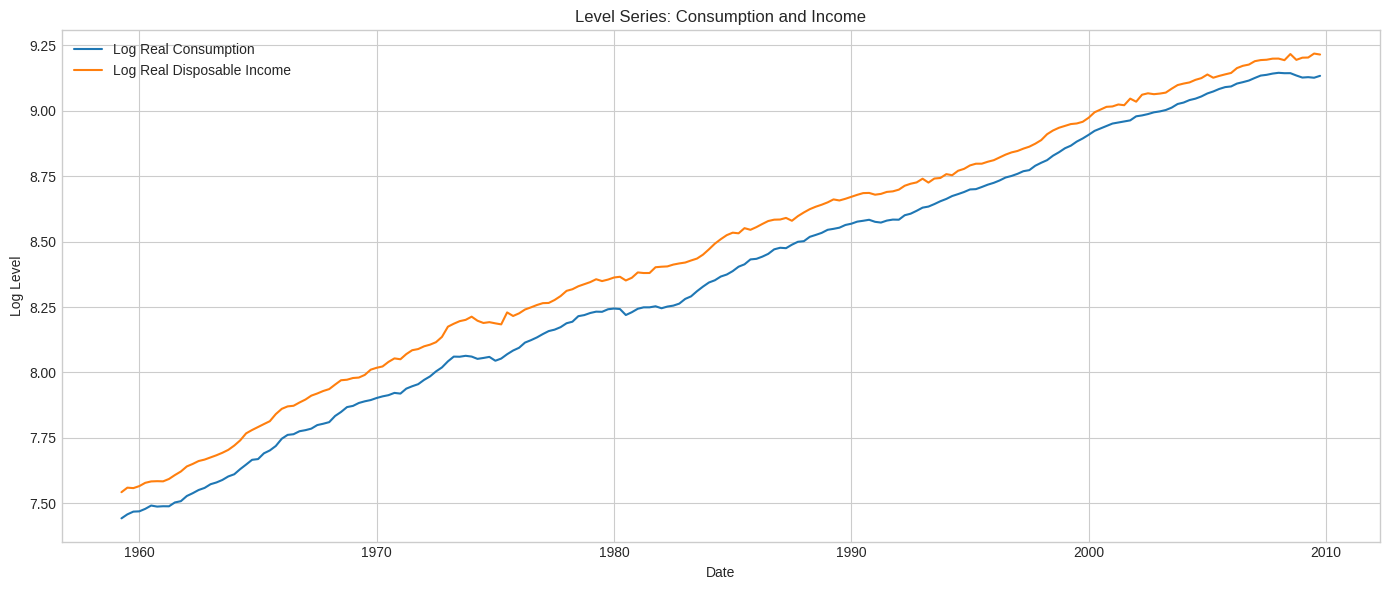

In [5]:
# ============================================
# 5. 로그 수준 시계열 플롯
# ============================================

plt.figure(figsize=(14, 6))
plt.plot(data.index, data["log_realcons"], label="Log Real Consumption", linewidth=1.5)
plt.plot(data.index, data["log_realdpi"], label="Log Real Disposable Income", linewidth=1.5)

plt.title("Level Series: Consumption and Income")
plt.xlabel("Date")
plt.ylabel("Log Level")
plt.legend()
plt.tight_layout()
plt.show()


## 5. 단위근 점검: 수준 시계열은 비정상적인가?
공적분은 일반적으로 각 변수가 I(1), 즉 단위근을 가진 비정상 시계열일 때 의미를 갖습니다.

여기서는 ADF 검정을 사용합니다.

- 귀무가설: 단위근이 존재한다 (비정상)
- p-value가 충분히 작으면 정상성에 더 가까움


In [6]:
# ============================================
# 6. ADF 검정 함수
# ============================================

from statsmodels.tsa.stattools import adfuller

def adf_report(series, name="Series"):
    result = adfuller(pd.Series(series).dropna(), autolag="AIC")
    print(f"===== {name} =====")
    print("ADF Statistic :", round(result[0], 4))
    print("ADF p-value   :", round(result[1], 4))
    print("-" * 40)


In [7]:
# ============================================
# 7. 수준 시계열 ADF 검정
# ============================================

for col in data.columns:
    adf_report(data[col], col)


===== log_realcons =====
ADF Statistic : -1.6449
ADF p-value   : 0.4597
----------------------------------------
===== log_realdpi =====
ADF Statistic : -2.6373
ADF p-value   : 0.0855
----------------------------------------


## 6. 1차 차분 시계열 만들기
이제 로그 수준의 1차 차분을 만들어 성장률에 가까운 형태를 확인합니다.  
공적분의 핵심 논리는 다음과 같습니다.

- 각 개별 시계열은 I(1)
- 하지만 특정 선형결합은 I(0)일 수 있음


In [8]:
# ============================================
# 8. 1차 차분 생성
# ============================================

diff_data = data.diff().dropna()
display(diff_data.head())


,log_realcons,log_realdpi
1959-06-30,0.015286,0.017234
1959-09-30,0.010386,-0.001720
1959-12-31,0.001084,0.007745
1960-03-31,0.009534,0.012453
1960-06-30,0.012572,0.005406


In [9]:
# ============================================
# 9. 차분 시계열 ADF 검정
# ============================================

for col in diff_data.columns:
    adf_report(diff_data[col], f"{col} (First Difference)")


===== log_realcons (First Difference) =====
ADF Statistic : -4.992
ADF p-value   : 0.0
----------------------------------------
===== log_realdpi (First Difference) =====
ADF Statistic : -9.0828
ADF p-value   : 0.0
----------------------------------------


## 7. 가짜 회귀의 직관 보기
비정상 시계열끼리 단순 회귀를 하면 높은 설명력이 나올 수 있습니다.  
이것이 항상 진짜 관계를 뜻하는 것은 아닙니다.

먼저 소비를 소득에 회귀해 보고, 잔차를 확인하겠습니다.


In [10]:
# ============================================
# 10. 수준 회귀와 잔차 추출
# ============================================

import statsmodels.api as sm

X = sm.add_constant(data["log_realdpi"])
ols_model = sm.OLS(data["log_realcons"], X).fit()

print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:           log_realcons   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.229e+05
Date:                Sun, 15 Mar 2026   Prob (F-statistic):          4.54e-282
Time:                        02:28:40   Log-Likelihood:                 504.26
No. Observations:                 203   AIC:                            -1005.
Df Residuals:                     201   BIC:                            -997.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.3758      0.025    -15.053      

In [11]:
# ============================================
# 11. 회귀 잔차 추출
# ============================================

residual = ols_model.resid
residual.name = "Spread"

display(residual.head())


,Spread
1959-03-31,0.034277
1959-06-30,0.031777
1959-09-30,0.043939
1959-12-31,0.037030
1960-03-31,0.033713


## 8. 스프레드(spread) 또는 잔차 플롯
공적분 직관의 핵심은 “개별 시계열은 떠다니지만, 둘의 거리(spread)는 제한된 범위 안에서 움직이는가?” 입니다.

따라서 두 변수의 회귀 잔차를 그려보고, 그것이 평균 주변에서 안정적으로 움직이는지 확인합니다.


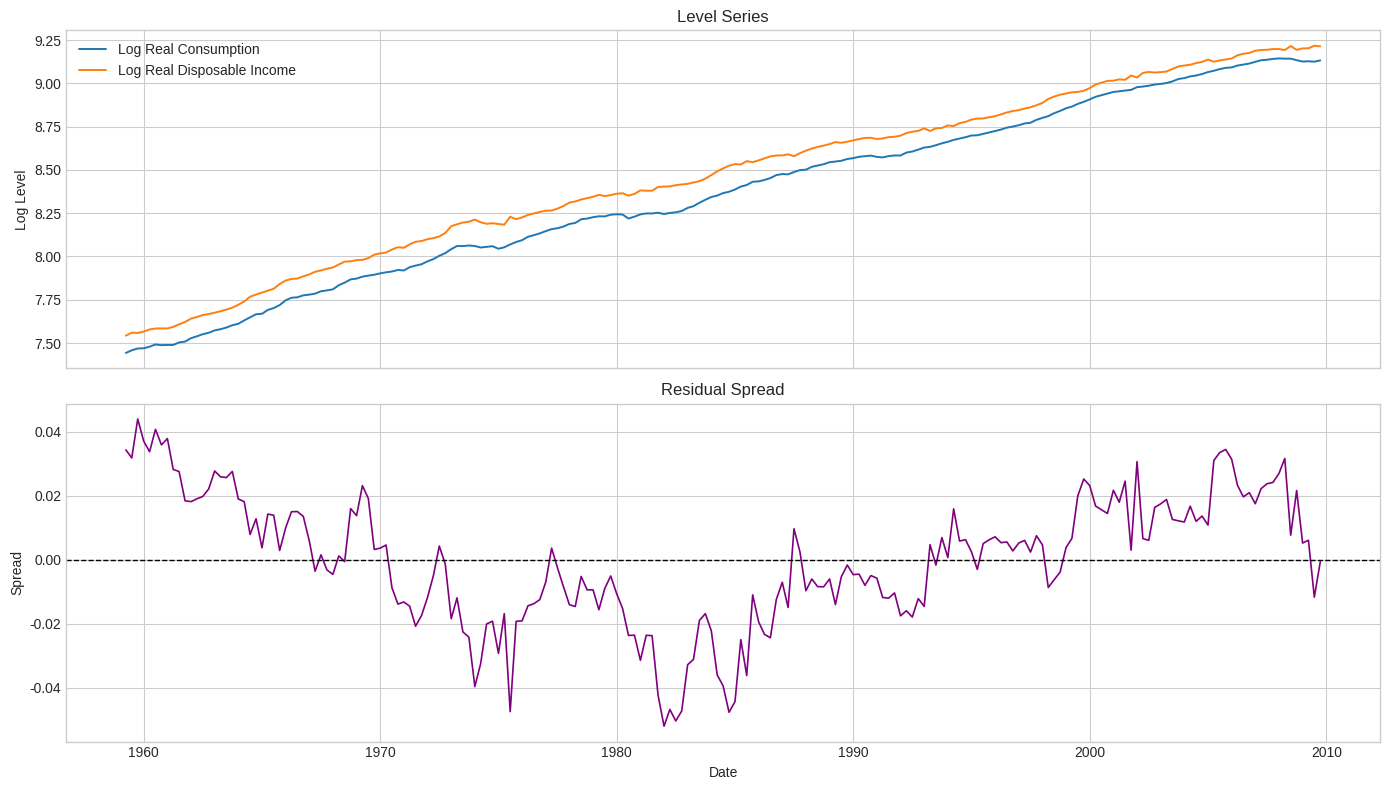

In [12]:
# ============================================
# 12. 잔차(스프레드) 플롯
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(data.index, data["log_realcons"], label="Log Real Consumption", linewidth=1.4)
axes[0].plot(data.index, data["log_realdpi"], label="Log Real Disposable Income", linewidth=1.4)
axes[0].set_title("Level Series")
axes[0].set_ylabel("Log Level")
axes[0].legend()

axes[1].plot(residual.index, residual, color="purple", linewidth=1.2)
axes[1].axhline(residual.mean(), color="black", linestyle="--", linewidth=1)
axes[1].set_title("Residual Spread")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Spread")

plt.tight_layout()
plt.show()


## 9. Engle–Granger 2단계 공적분 검정
Engle–Granger 검정은 다음 아이디어를 사용합니다.

1. 한 변수로 다른 변수를 회귀한다.
2. 그 잔차가 정상 시계열인지 검정한다.

즉, 두 비정상 시계열의 선형 결합이 정상이라면 공적분 관계가 있다고 본다.


In [13]:
# ============================================
# 13. Engle-Granger cointegration test
# ============================================

from statsmodels.tsa.stattools import coint

score, pvalue, crit = coint(data["log_realcons"], data["log_realdpi"])

print("Cointegration test statistic:", round(score, 4))
print("Cointegration p-value      :", round(pvalue, 6))
print("Critical values            :", crit)


Cointegration test statistic: -2.5394
Cointegration p-value      : 0.261975
Critical values            : [-3.95147899 -3.36654523 -3.0655127 ]


## 10. 잔차 정상성 직접 확인
Engle–Granger 검정과 별도로, 회귀 잔차에 대해 ADF 검정을 직접 수행해 보면 공적분 직관을 더 쉽게 이해할 수 있습니다.

만약 잔차가 정상이라면, 이는 두 변수의 장기적 거리가 일정 범위 안에서 유지된다는 뜻입니다.


In [14]:
# ============================================
# 14. 잔차의 ADF 검정
# ============================================

adf_report(residual, "Residual Spread")


===== Residual Spread =====
ADF Statistic : -2.5354
ADF p-value   : 0.1071
----------------------------------------


## 11. Johansen 접근과 공적분 rank
Engle–Granger는 2변수 예시에서 직관적이지만, 다변량 공적분에서는 Johansen 접근이 더 일반적입니다.

여기서는 `select_coint_rank()`를 사용하여 공적분 rank를 확인합니다.


In [15]:
# ============================================
# 15. Johansen rank selection
# ============================================

from statsmodels.tsa.vector_ar.vecm import select_coint_rank

rank_test = select_coint_rank(data, det_order=0, k_ar_diff=2, method="trace", signif=0.05)
print(rank_test.summary())


Johansen cointegration test using trace test statistic with 5% significance level
r_0 r_1 test statistic critical value
-------------------------------------
  0   2          15.53          15.49
  1   2          3.440          3.841
-------------------------------------


## 12. VECM을 위한 lag 선택
VECM은 차분항의 시차와 공적분 rank를 함께 고려해야 합니다.  
여기서는 `select_order()`를 통해 적절한 차분 시차 수를 탐색합니다.


In [16]:
# ============================================
# 16. VECM lag selection
# ============================================

from statsmodels.tsa.vector_ar.vecm import select_order

lag_order = select_order(data, maxlags=8, deterministic="co")
print(lag_order.summary())


 VECM Order Selection (* highlights the minimums)
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0      -19.65      -19.51   2.930e-09      -19.59
1      -19.80     -19.60*   2.521e-09     -19.72*
2      -19.81      -19.54   2.483e-09      -19.70
3      -19.81      -19.47   2.495e-09      -19.67
4      -19.80      -19.39   2.526e-09      -19.63
5     -19.82*      -19.34  2.479e-09*      -19.63
6      -19.79      -19.25   2.546e-09      -19.57
7      -19.78      -19.17   2.569e-09      -19.54
8      -19.77      -19.10   2.592e-09      -19.50
-------------------------------------------------


In [17]:
# ============================================
# 17. AIC 기준 차분 시차 선택
# ============================================

selected_k_ar_diff = lag_order.selected_orders["aic"]
if selected_k_ar_diff is None:
    selected_k_ar_diff = 1

selected_k_ar_diff = int(selected_k_ar_diff)
print("Selected k_ar_diff by AIC:", selected_k_ar_diff)


Selected k_ar_diff by AIC: 5


## 13. VECM 적합
이제 공적분 rank와 lag를 지정하여 VECM을 적합합니다.

여기서는 공적분 rank를 1로 두고,  
장기 관계 하나가 존재한다고 가정합니다.


In [18]:
# ============================================
# 18. VECM fit
# ============================================

from statsmodels.tsa.vector_ar.vecm import VECM

vecm_model = VECM(
    data,
    k_ar_diff=selected_k_ar_diff,
    coint_rank=1,
    deterministic="co"
)

vecm_results = vecm_model.fit()
print(vecm_results.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation log_realcons
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0096      0.013      0.730      0.466      -0.016       0.036
L1.log_realcons     0.1262      0.080      1.583      0.114      -0.030       0.282
L1.log_realdpi      0.1484      0.060      2.485      0.013       0.031       0.265
L2.log_realcons     0.1882      0.082      2.301      0.021       0.028       0.349
L2.log_realdpi     -0.0205      0.063     -0.328      0.743      -0.143       0.102
L3.log_realcons     0.2329      0.082      2.827      0.005       0.071       0.394
L3.log_realdpi     -0.0014      0.062     -0.022      0.982      -0.123       0.121
L4.log_realcons    -0.0447      0.083     -0.537      0.591      -0.208       0.118
L4.log_realdpi     -0.0388      0.062     -0.625      0.532      -0.

## 14. 공적분 벡터와 조정속도 해석
VECM 결과에서 중요한 두 요소는 다음과 같습니다.

1. **beta (공적분 벡터)**  
   - 장기 균형 관계를 정의하는 계수
2. **alpha (조정속도)**  
   - 균형에서 벗어났을 때 각 변수가 얼마나 빠르게 복귀하는지 보여줌

특히 alpha가 음수이면서 유의미하다면, 균형 오차를 줄이는 방향으로 움직인다고 해석할 수 있습니다.


In [19]:
# ============================================
# 19. alpha와 beta 확인
# ============================================

alpha_df = pd.DataFrame(vecm_results.alpha, index=data.columns, columns=["alpha"])
beta_df = pd.DataFrame(vecm_results.beta, index=data.columns, columns=["beta"])

print("Adjustment speed (alpha):")
display(alpha_df)

print("Cointegration vector (beta):")
display(beta_df)


Adjustment speed (alpha):


,alpha
log_realcons,0.006563
log_realdpi,0.069247


Cointegration vector (beta):


,beta
log_realcons,1.000000
log_realdpi,-1.083303


## 15. Error Correction Term 만들기
공적분 관계가 있다면, 다음과 같은 오차수정항(ECT)을 만들 수 있습니다.

<code>ECT_t = beta' x_t</code>

이 값이 크거나 작다는 것은 장기 균형에서 얼마나 벗어났는지를 의미합니다.


In [20]:
# ============================================
# 20. Error Correction Term 계산
# ============================================

ect = data.values @ vecm_results.beta
ect_series = pd.Series(ect.flatten(), index=data.index, name="ECT")

display(ect_series.head())


,ECT
1959-03-31,-0.728289
1959-06-30,-0.731672
1959-09-30,-0.719422
1959-12-31,-0.726728
1960-03-31,-0.730684


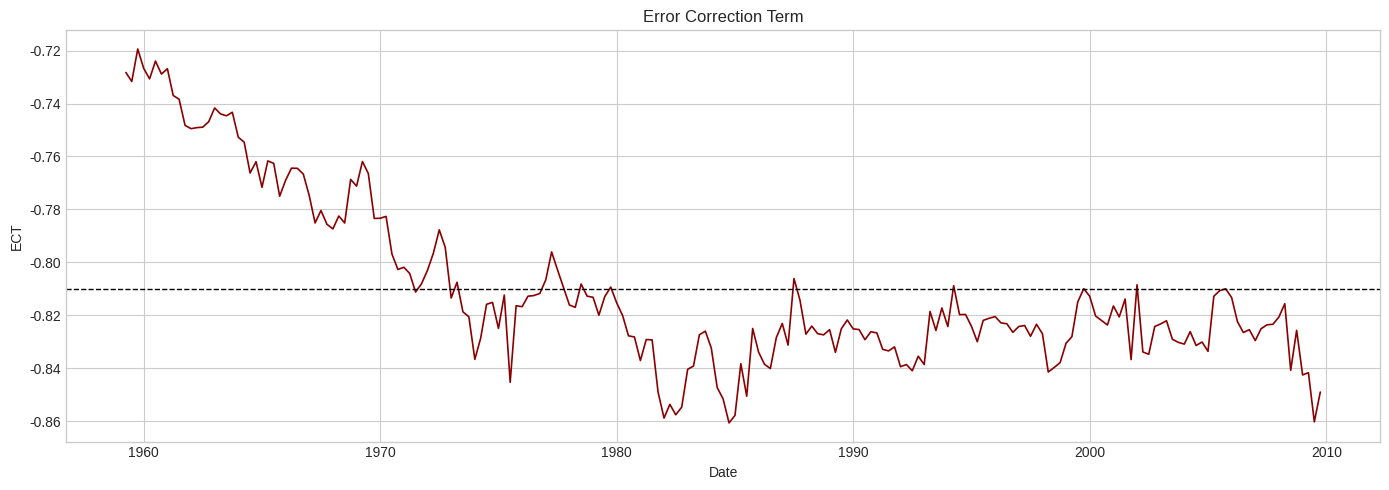

In [21]:
# ============================================
# 21. ECT 시각화
# ============================================

plt.figure(figsize=(14, 5))
plt.plot(ect_series.index, ect_series, color="darkred", linewidth=1.2)
plt.axhline(ect_series.mean(), color="black", linestyle="--", linewidth=1)

plt.title("Error Correction Term")
plt.xlabel("Date")
plt.ylabel("ECT")
plt.tight_layout()
plt.show()


## 16. Train / Test 분할과 VECM 예측
이제 마지막 8개 분기를 테스트 구간으로 두고 VECM 예측을 수행합니다.  
이 예측은 단기 변화와 장기 균형 정보를 함께 반영합니다.


In [22]:
# ============================================
# 22. Train / Test split
# ============================================

test_size = 8

train = data.iloc[:-test_size]
test = data.iloc[-test_size:]

print("Train length:", len(train))
print("Test length :", len(test))


Train length: 195
Test length : 8


In [23]:
# ============================================
# 23. Train 데이터로 VECM 재적합
# ============================================

vecm_train = VECM(
    train,
    k_ar_diff=selected_k_ar_diff,
    coint_rank=1,
    deterministic="co"
).fit()

print(vecm_train.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation log_realcons
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0095      0.013      0.724      0.469      -0.016       0.035
L1.log_realcons     0.0848      0.081      1.050      0.294      -0.074       0.243
L1.log_realdpi      0.1610      0.062      2.600      0.009       0.040       0.282
L2.log_realcons     0.1612      0.083      1.954      0.051      -0.000       0.323
L2.log_realdpi     -0.0202      0.064     -0.316      0.752      -0.145       0.105
L3.log_realcons     0.2342      0.083      2.825      0.005       0.072       0.397
L3.log_realdpi     -0.0201      0.063     -0.318      0.751      -0.144       0.104
L4.log_realcons    -0.0310      0.084     -0.370      0.712      -0.195       0.133
L4.log_realdpi     -0.0446      0.063     -0.708      0.479      -0.

In [24]:
# ============================================
# 24. VECM forecast
# ============================================

forecast_values = vecm_train.predict(steps=len(test))

forecast_df = pd.DataFrame(
    forecast_values,
    index=test.index,
    columns=test.columns
)

display(forecast_df.head())


,log_realcons,log_realdpi
2007-12-31,9.148678,9.207092
2008-03-31,9.155324,9.213529
2008-06-30,9.162926,9.221009
2008-09-30,9.171701,9.229577
2008-12-31,9.180295,9.237441


## 17. 베이스라인과 비교
공적분/VECM도 결국 예측 도구로 쓰일 수 있으므로,  
단순 baseline과 비교해 보는 것이 유용합니다.

여기서는 마지막 관측값을 계속 유지하는 Naive baseline을 사용합니다.


In [25]:
# ============================================
# 25. Naive baseline
# ============================================

naive_forecast = pd.DataFrame(
    np.tile(train.iloc[-1].values, (len(test), 1)),
    index=test.index,
    columns=test.columns
)

display(naive_forecast.head())


,log_realcons,log_realdpi
2007-12-31,9.14159,9.198662
2008-03-31,9.14159,9.198662
2008-06-30,9.14159,9.198662
2008-09-30,9.14159,9.198662
2008-12-31,9.14159,9.198662


In [26]:
# ============================================
# 26. 평가 함수
# ============================================

from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_multivariate(y_true_df, y_pred_df, model_name="Model"):
    rows = []
    for col in y_true_df.columns:
        mae = mean_absolute_error(y_true_df[col], y_pred_df[col])
        rmse = np.sqrt(mean_squared_error(y_true_df[col], y_pred_df[col]))
        rows.append({
            "Model": model_name,
            "Variable": col,
            "MAE": mae,
            "RMSE": rmse
        })
    return pd.DataFrame(rows)


In [27]:
# ============================================
# 27. VECM vs Naive 성능 비교
# ============================================

eval_vecm = evaluate_multivariate(test, forecast_df, "VECM")
eval_naive = evaluate_multivariate(test, naive_forecast, "Naive")

eval_all = pd.concat([eval_vecm, eval_naive], ignore_index=True)
display(eval_all.sort_values(["Variable", "RMSE"]))


,Model,Variable,MAE,RMSE
2,Naive,log_realcons,0.008326,0.010039
0,VECM,log_realcons,0.041681,0.048881
3,Naive,log_realdpi,0.008914,0.011287
1,VECM,log_realdpi,0.028410,0.031865


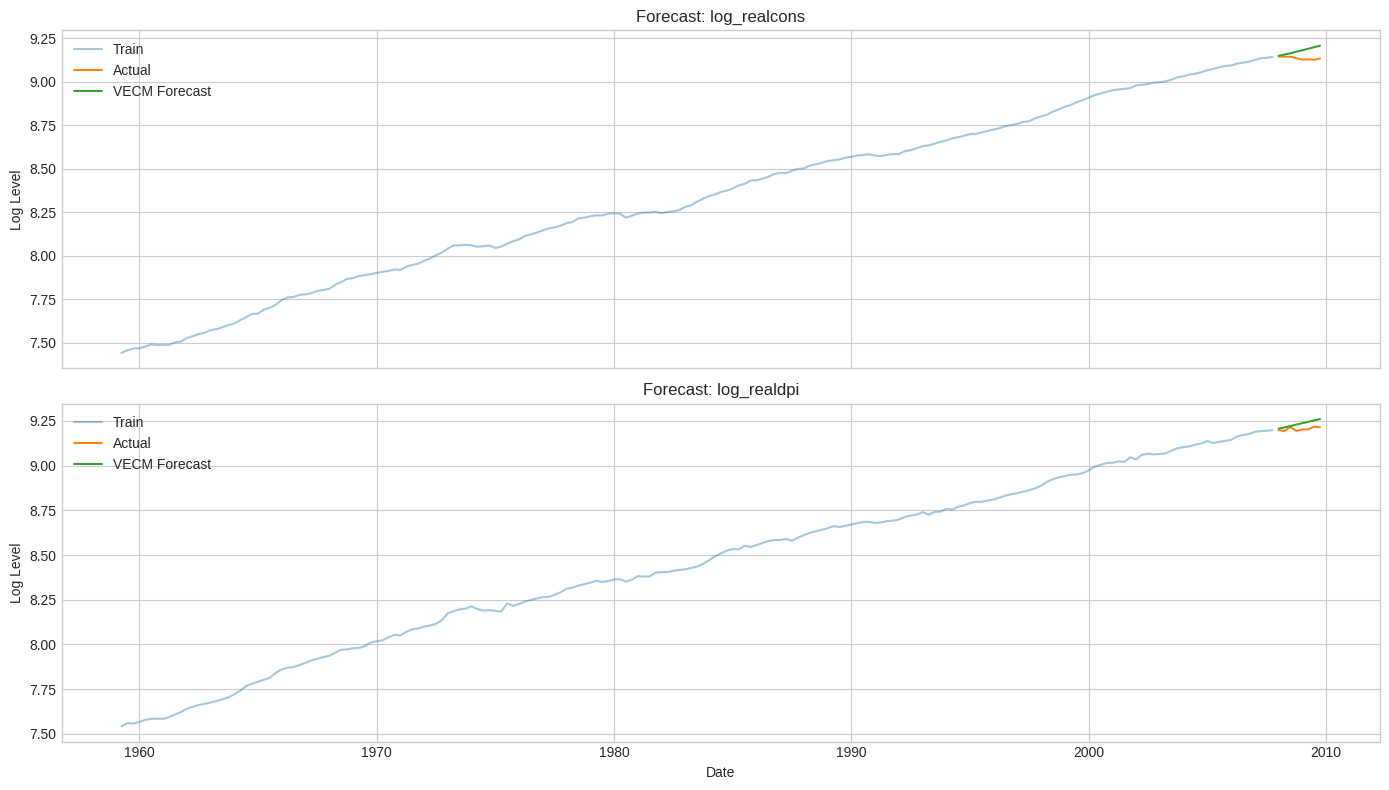

In [28]:
# ============================================
# 28. 실제값 vs VECM 예측값
# ============================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for i, col in enumerate(test.columns):
    axes[i].plot(train.index, train[col], label="Train", alpha=0.4)
    axes[i].plot(test.index, test[col], label="Actual", linewidth=1.4)
    axes[i].plot(forecast_df.index, forecast_df[col], label="VECM Forecast", linewidth=1.4)
    axes[i].set_title(f"Forecast: {col}")
    axes[i].set_ylabel("Log Level")
    axes[i].legend()

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()


## 18. 해석 포인트
이번 장의 결과를 해석할 때 중요한 질문은 다음과 같습니다.

- 개별 시계열은 비정상인데, 잔차(spread)는 정상적인가?
- Engle–Granger p-value가 충분히 작아 공적분을 지지하는가?
- VECM의 alpha는 어느 변수가 장기균형 복귀를 주도하는지 보여주는가?
- 예측 성능에서 VECM이 Naive보다 항상 좋은가, 아니면 주로 구조 해석에 더 강점이 있는가?

즉, 공적분과 VECM의 가치는 단순 forecast score 개선뿐 아니라,  
**장기 관계를 보존한 채 단기 조정 과정을 해석할 수 있다는 점**에 있습니다.


## 19. 자주 발생하는 실수 (Common Mistakes)
이번 장에서 특히 자주 발생하는 실수는 다음과 같습니다.

1. **상관관계와 공적분을 혼동하는 실수**  
   두 시계열이 같이 증가한다고 해서 자동으로 공적분인 것은 아닙니다.

2. **I(0) 변수에 공적분 개념을 그대로 적용하는 실수**  
   공적분은 일반적으로 I(1) 변수들 사이의 장기 관계를 다룹니다.

3. **수준 회귀의 높은 R²를 진짜 관계로 오해하는 실수**  
   비정상 시계열끼리의 회귀는 가짜 회귀일 수 있습니다.

4. **alpha 부호를 해석하지 않는 실수**  
   조정속도는 단순 통계량이 아니라, 균형 복귀 방향을 보여주는 핵심 정보입니다.

5. **공적분 rank를 충분히 확인하지 않는 실수**  
   다변량 시스템에서는 rank 선택 자체가 중요한 모델링 단계입니다.


## 20. 실습 정리
이번 실습에서 확인한 핵심은 다음과 같습니다.

- 수준 시계열이 비정상적이어도, 특정 선형결합은 정상일 수 있다.
- 이것이 바로 공적분이며, 장기균형 관계의 통계적 표현이다.
- Engle–Granger 검정은 2변수 공적분 직관을 이해하기에 매우 유용하다.
- Johansen 접근은 다변량 공적분 rank를 다루는 데 적합하다.
- VECM은 단기 차분 동학과 장기 균형 복귀를 함께 모델링한다.
- alpha는 어느 변수가 균형 오차를 수정하는지를 보여주는 핵심 파라미터이다.


## 21. 연습문제 (Exercises)

1. `realcons`와 `realdpi` 대신 다른 2개 거시 수준 변수를 선택하여 Engle–Granger 검정을 수행하시오.

2. 수준 회귀의 잔차가 정상적이지 않다면, 그것이 의미하는 바를 설명하시오.

3. Johansen rank 결과가 1보다 크다면, 경제적으로 어떤 의미를 가질 수 있는지 논의하시오.

4. VECM의 alpha가 양수로 추정되었다면, 장기 균형 복귀 관점에서 어떤 해석 문제가 생길 수 있는지 설명하시오.

5. 공적분 관계가 존재하는 경우, 단순 차분 VAR보다 VECM이 더 적절할 수 있는 이유를 설명하시오.
